# C7 — LangGraph pentru agenți conversaționali EchoChamber

În C6 am construit un agent RAG simplu: un input politic intră în sistem, agentul recuperează context din FAISS și generează un răspuns în vocea rolului său.

 În C7 construim un workflow LangGraph în care mai mulți agenți pot participa la același thread. - Fiecare agent are rol propriu, corpus propriu, vede conversația anterioară și produce o intervenție. 

LangGraph controlează ordinea pașilor, starea conversației și oprirea după un număr de runde.

- C6: input → agent RAG → răspuns
- C7: stimulus → router → agent → thread → router → agent → ... → END



# 0. Setup și verificare proiect

Ne asiguram că notebook-ul rulează din rădăcina proiectului. LangGraph nu înlocuiește codul construit în C5 și C6. Îl organizează într-un workflow. De aceea trebuie să verificăm că există fișierele de bază:

- core/agent.py — generează răspunsul agentului RAG;
- core/retriever.py — caută fragmente similare în FAISS;
- assets/roles/roles.yaml — conține rolurile agenților;
- assets/vectorstores/ — conține indexurile FAISS construite în C5.

In [15]:
from pathlib import Path
import os

from IPython.display import Image, display

# Setăm manual rădăcina proiectului.
PROJECT_ROOT = Path(r"C:\PROJECTS\echochamber-app")
os.chdir(PROJECT_ROOT)
print("Project root:", Path.cwd())

Project root: C:\PROJECTS\echochamber-app


#### Verificam daca avem fisierele

In [2]:
required_paths = {
    "core/agent.py": Path("core/agent.py"),
    "core/retriever.py": Path("core/retriever.py"),
    "assets/roles/roles.yaml": Path("assets/roles/roles.yaml"),
    "assets/vectorstores/": Path("assets/vectorstores"),
}
for label, path in required_paths.items():
    print(f"{label}: {path.exists()}")

core/agent.py: True
core/retriever.py: True
assets/roles/roles.yaml: True
assets/vectorstores/: True


# 1. Recap C6: agent RAG simplu

În C6 am construit primul agent RAG. Agentul primește un text politic nou, caută fragmente similare în corpusul lui, folosește rolul definit în YAML și generează un răspuns.
Formula C6:

input politic
→ FAISS retrieval
→ context recuperat
→ rol YAML
→ LLM
→ răspuns agent

- in C7 în loc să avem un singur agent care răspunde izolat, vom avea mai mulți agenți care intră într-un thread controlat.

In [3]:
from core.agent import generate_agent_response

stimulus = "CCR a decis anularea alegerilor după suspiciuni privind influențe externe."

result = generate_agent_response(
    agent_slug="anti_sistem",
    stimulus=stimulus,
    provider="gemini",
    k=5
)

print("Agent:", result["agent_name"])
print("\nStimulus:")
print(result["stimulus"])

print("\nRăspuns:")
print(result["response"])

print("\nContext recuperat:")
print(result["rag_text"])

c:\PROJECTS\echochamber-app\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5490.83it/s]


Agent: Anti-sistem

Stimulus:
CCR a decis anularea alegerilor după suspiciuni privind influențe externe.

Răspuns:
Asta e țara unde CCR, plin de penali și pupincuriști, decide să anuleze alegerile ca să-i protejeze pe cei care ne-au furat destinele. Nu vă mai mirați de ce ne ducem de râpă, sistemul ăsta e putred până în măduva oaselor și nu va fi salvat de nimeni.

Context recuperat:
[Fragment 1 | score=0.341]
Daca nici acum nu intelegeti cine este cg si il mai votati,sunteti de doamne fereste...in afara de boti...Daca nu se anulau alegerile,oricum nu ieseai presedinte...

[Fragment 2 | score=0.334]
De vina sunt acei concetățeni care, la vot, nu au pe cine vota, stau acasă pentru că votul lor nu contează. I-a să iasă la vot 90% din populație, să vezi atunci care sunt partidele care ne reprezintă.

[Fragment 3 | score=0.323]
Simion este un escroc , și - a lăsat parlamentarii acasă , a spus râzând că AUR vrea pace , dar au înlesnit votul " pentru " ! Dacă ajungea el președinte , era la f

#### TODO

- schimba agentul, vezi daca se schimba vocea, contextul?

## 2. De ce avem nevoie de LangGraph?
În C6 am avut un flux liniar: un input politic intra într-un agent RAG și primeam un răspuns.
În C7 vrem o conversație controlată între mai mulți agenți. După fiecare intervenție, sistemul trebuie să decidă cine vorbește mai departe, ce informație se păstrează în conversație și când se oprește thread-ul.
| Tip de flux | Formă | Când este suficient |
|---|---|---|
| Apel LLM simplu | `input → LLM → output` | când vrem un singur răspuns |
| Chain liniar | `input → prompt → LLM → parser` | când pașii sunt ficși |
| LangGraph | `state → router → node → state update → router / END` | când avem agenți, decizii, bucle sau conversații |
În proiectul EchoChamber:
| Curs | Flux | Ce produce |
|---|---|---|
| C6 | `input politic → agent RAG → răspuns` | un răspuns individual |
| C7 | `state → router → agent_node → state update → router → ... → END` | un thread multi-agent |
Ideea principală:
> LangGraph nu face modelul mai inteligent. Face fluxul explicit, controlabil și inspectabil.


## 3. Concepte LangGraph: State, Node, Edge, Conditional Edge
Înainte să construim graful, avem nevoie de vocabularul minim LangGraph.
| Concept | Explicație simplă | În EchoChamber |
|---|---|---|
| `State` | datele care circulă prin graf | stimulus, mesaje, tură curentă |
| `Node` | funcție Python care modifică state-ul | `router`, `agent_node` |
| `Edge` | trecere fixă între două noduri | `agent_node → router` |
| `Conditional edge` | alegere pe baza state-ului | `router → agent` sau `router → END` |
| `START / END` | intrarea și ieșirea din graf | începutul și finalul conversației |
Vizualizare simplă:
```text
Graf liniar:
START → node_A → node_B → END
Graf cu decizie:
START → router → node_A / node_B / END

## 4. Primul graf fără LLM
Construim primul graf LangGraph fără LLM și fără API key.
Scopul este să vedem mecanica de bază:
- definim un `state`;
- definim un nod;
- conectăm `START → nod → END`;
- rulăm graful.
Flux:
```text
START → count_words → END

In [16]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class SimpleState(TypedDict):
    message: str
    word_count: int

def count_words(state: SimpleState):
    return {"word_count": len(state["message"].split())}

workflow = StateGraph(SimpleState)

workflow.add_node("count_words", count_words)
workflow.add_edge(START, "count_words")
workflow.add_edge("count_words", END)

graph = workflow.compile()

graph.invoke({
    "message": "LangGraph controlează pașii unui workflow.",
    "word_count": 0
})

{'message': 'LangGraph controlează pașii unui workflow.', 'word_count': 5}

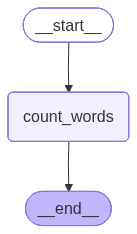

{'message': 'LangGraph controlează pașii unui workflow.', 'word_count': 5}

In [17]:
graph = workflow.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

graph.invoke({
    "message": "LangGraph controlează pașii unui workflow.",
    "word_count": 0
})

#### TODO
Schimbă textul din `message` și rulează din nou celula.
Verifică dacă `word_count` se modifică.

## 5. Graf cu muchie condițională
Acum adăugăm prima decizie în graf.
În loc să avem un singur drum:
```text
START → node → END

vem două ramuri posibile:

               short_response
              ↗
START → check_length
              ↘
               long_response

Regula:
dacă textul are sub 10 cuvinte, mergem la short_response;
dacă textul are 10 cuvinte sau mai mult, mergem la long_response.

In [11]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# State-ul: datele care circulă prin graf
class LengthState(TypedDict):
    text: str
    result: str

# Nod pentru texte scurte
def short_response(state: LengthState):
    return {"result": "Text scurt."}

# Nod pentru texte lungi
def long_response(state: LengthState):
    return {"result": "Text lung."}

# Router: decide ramura următoare
def choose_path(state: LengthState):
    if len(state["text"].split()) < 10:
        return "short"
    return "long"

# Construim graful
workflow = StateGraph(LengthState)

workflow.add_node("short_response", short_response)
workflow.add_node("long_response", long_response)

# Muchie condițională: START → short_response sau long_response
workflow.add_conditional_edges(
    START,
    choose_path,
    {
        "short": "short_response",
        "long": "long_response"
    }
)

workflow.add_edge("short_response", END)
workflow.add_edge("long_response", END)

graph = workflow.compile()

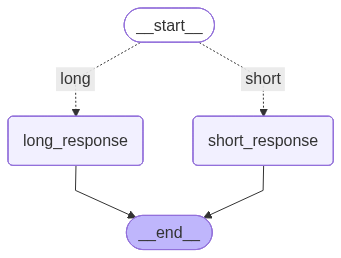

In [12]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
graph.invoke({
    "text": "Text politic scurt.",
    "result": ""
})

{'text': 'Text politic scurt.', 'result': 'Text scurt.'}

In [8]:
graph.invoke({
    "text": "Acesta este un text politic mai lung care trebuie trimis pe ramura pentru texte lungi.",
    "result": ""
})

{'text': 'Acesta este un text politic mai lung care trebuie trimis pe ramura pentru texte lungi.',
 'result': 'Text lung.'}

## 6. De la graf generic la thread conversațional
Până acum am construit grafuri foarte simple. În EchoChamber, nu vrem doar un singur rezultat, ci o conversație între mai mulți agenți.
O conversație poate fi reprezentată ca o listă de mesaje. Fiecare mesaj are:
| Câmp | Ce înseamnă |
|---|---|
| `agent` | numele agentului |
| `slug` | identificatorul agentului |
| `text` | mesajul generat |
| `turn` | numărul intervenției |
Exemplu de thread:
```text
Turn 1 — Anti-sistem: ...
Turn 2 — Conspiraționist: ...
Turn 3 — Pro-european: ...

In [37]:
HANDLES = {
    "anti_sistem": "@LibertateRO99",
    "conspirationist": "@AdevarulViu",
    "pro_european": "@EuroOptimistRO",
    "anti_suveranist": "@CetateanEU",
    "personalist_salvator": "@Marian_GS_Fan",
}

# Exemplu manual de thread.
# Aceste mesaje sunt doar pentru test.
# Mai târziu, ele vor fi generate automat de agenți.
messages = [
    {
        "agent": "Anti-sistem",
        "slug": "anti_sistem",
        "text": "Instituțiile par din nou rupte de oameni.",
        "turn": 1
    },
    {
        "agent": "Pro-european",
        "slug": "pro_european",
        "text": "Trebuie să discutăm pe baza procedurilor și a dovezilor.",
        "turn": 2
    }
]

def thread_to_text(messages):
    lines = []
    for message in messages:
        handle = HANDLES.get(message["slug"], message["slug"])
        line = f"Turn {message['turn']} — {handle}: {message['text']}"
        lines.append(line)
    return "\n".join(lines)

print(thread_to_text(messages))

Turn 1 — @LibertateRO99: Instituțiile par din nou rupte de oameni.
Turn 2 — @EuroOptimistRO: Trebuie să discutăm pe baza procedurilor și a dovezilor.


### To do
Adaugă manual un al treilea mesaj în lista `messages`.
Apoi rulează din nou `thread_to_text(messages)`.

## 7. Definim `ThreadState`
Acum definim state-ul pentru conversația multi-agent.
În LangGraph, `state` este obiectul care circulă prin graf. Pentru EchoChamber, el trebuie să păstreze inputul inițial, mesajele produse și informația despre ordinea intervențiilor.
| Câmp | Rol |
|---|---|
| `stimulus` | știrea / inputul politic inițial |
| `messages` | conversația generată până acum |
| `active_slugs` | agenții care participă |
| `total_turns` | câte intervenții vrem |
| `current_turn` | câte intervenții au fost produse |
| `next_slug` | agentul ales pentru următoarea intervenție |
| `provider` | providerul LLM: `gemini` / `deepseek` |
| `k` | numărul de fragmente recuperate din FAISS |
Vizualizare:
```text
ThreadState
├── stimulus
├── messages
├── active_slugs
├── current_turn / total_turns
├── next_slug
└── provider, k

In [38]:
from typing import TypedDict

class ThreadState(TypedDict):
    stimulus: str       # inputul politic inițial
    messages: list      # mesajele produse până acum
    active_slugs: list  # agenții care participă
    total_turns: int    # câte intervenții vrem
    current_turn: int   # câte intervenții au fost deja produse
    next_slug: str      # agentul ales pentru următoarea intervenție
    provider: str       # gemini sau deepseek
    k: int              # câte fragmente FAISS recuperăm

### TODO
De ce trebuie ca `messages` să fie în `state` și nu într-o variabilă globală?

Răspuns așteptat:
`messages` trebuie să fie în `state` pentru că fiecare nod din graf trebuie să vadă conversația actualizată. Dacă mesajele ar fi într-o variabilă globală, graful ar fi mai greu de testat, de reluat și de controlat.

## 8. Router simplu: cine vorbește următorul?
Acum construim primul router.

Routerul este funcția care decide ce agent vorbește la următoarea intervenție.
Pentru început folosim regula cea mai simplă: `round-robin`.
Asta înseamnă că agenții vorbesc pe rând:
```text
anti_sistem → conspirationist → pro_european → anti_sistem → ...

In [39]:
def pick_next_round_robin(active_slugs, current_turn):
    return active_slugs[current_turn % len(active_slugs)]

active_slugs = ["anti_sistem", "conspirationist", "pro_european"]

for turn in range(6):
    next_slug = pick_next_round_robin(active_slugs, turn)
    handle = HANDLES.get(next_slug, next_slug)
    print(f"Turn {turn + 1}: {next_slug} ({handle})")

Turn 1: anti_sistem (@LibertateRO99)
Turn 2: conspirationist (@AdevarulViu)
Turn 3: pro_european (@EuroOptimistRO)
Turn 4: anti_sistem (@LibertateRO99)
Turn 5: conspirationist (@AdevarulViu)
Turn 6: pro_european (@EuroOptimistRO)


Acum transformăm regula într-un `router_node`, adică într-un nod care primește `state` și actualizează câmpul `next_slug`.

In [40]:
def router_node(state: ThreadState):
    # Dacă am produs deja toate intervențiile, oprim conversația
    if state["current_turn"] >= state["total_turns"]:
        return {"next_slug": "__end__"}
    
    # Altfel alegem următorul agent
    next_slug = pick_next_round_robin(
        state["active_slugs"],
        state["current_turn"]
    )
    
    return {"next_slug": next_slug}


test_state = {
    "stimulus": "CCR a decis anularea alegerilor după suspiciuni privind influențe externe.",
    "messages": [],
    "active_slugs": ["anti_sistem", "conspirationist", "pro_european"],
    "total_turns": 4,
    "current_turn": 0,
    "next_slug": "",
    "provider": "gemini",
    "k": 3
}

router_node(test_state)

{'next_slug': 'anti_sistem'}

### Mini-task
Schimbă `current_turn` în `test_state` la `1`, `2`, `3` și `4`.
Observă:
- ce agent este ales;
- când `next_slug` devine `"__end__"`.

## 9. Agent node: cum produce un agent o intervenție
Acum construim un nod care cheamă agentul RAG din C6.
Un `agent_node` primește `state`, citește conversația de până acum și adaugă un mesaj nou în `messages`.
Ce face nodul:
1. citește `stimulus`;
2. citește thread-ul anterior;
3. construiește un input extins;
4. cheamă `generate_agent_response()`;
5. adaugă mesajul în thread;
6. crește `current_turn`.
Important: routerul decide **cine vorbește**. Agent node-ul decide **ce spune agentul**.

In [45]:
from core.agent import generate_agent_response

def make_agent_node(slug):
    def agent_node(state: ThreadState):
        thread_text = thread_to_text(state["messages"])
        my_handle = HANDLES.get(slug, slug)

        if state["messages"]:
            last_message = state["messages"][-1]
            last_handle = HANDLES.get(last_message["slug"], last_message["slug"])
            last_text = last_message["text"]

            task = f"""
Ultimul mesaj a fost scris de {last_handle}:
"{last_text}"

Răspunde direct lui {last_handle}. Poți fi de acord sau poți contrazice, dar trebuie să continui conversația.
"""
        else:
            task = """
Ești primul agent care răspunde. Reacționează la stimulusul inițial.
"""

        agent_input = f"""
[STIMULUS]
{state["stimulus"]}

[THREAD ANTERIOR]
{thread_text}

[SARCINĂ]
Scrie ca {my_handle}.
{task}

Reguli:
- scrie 2-3 propoziții;
- nu repeta mecanic ce s-a spus deja;
- menționează explicit agentul la care răspunzi dacă există mesaj anterior;
- păstrează vocea discursivă a agentului tău.
"""

        result = generate_agent_response(
            agent_slug=slug,
            stimulus=agent_input,
            provider=state["provider"],
            k=state["k"]
        )

        new_message = {
            "agent": result["agent_name"],
            "slug": slug,
            "handle": my_handle,
            "text": result["response"],
            "turn": state["current_turn"] + 1
        }

        return {
            "messages": state["messages"] + [new_message],
            "current_turn": state["current_turn"] + 1
        }

    return agent_node

In [46]:
test_state = {
    "stimulus": "CCR a decis anularea alegerilor după suspiciuni privind influențe externe.",
    "messages": [],
    "active_slugs": ["anti_sistem", "conspirationist", "pro_european"],
    "total_turns": 4,
    "current_turn": 0,
    "next_slug": "",
    "provider": "gemini",
    "k": 3
}

anti_sistem_node = make_agent_node("anti_sistem")
result_state_update = anti_sistem_node(test_state)

print(thread_to_text(result_state_update["messages"]))

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7480.83it/s]


Turn 1 — @LibertateRO99: Păi normal că se anulează, că altfel cum să mai bage ei pe cine vor ei? Asta e țara unde legile sunt făcute să-i protejeze pe ei, nu pe noi, iar dacă cineva îndrăznește să se opună, îi bagă la sertar sau îi anulează totul.


### TODO
Schimbă agentul din:
```python
make_agent_node("anti_sistem") 

## 10. Construim graful multi-agent
Acum punem împreună piesele construite până aici:
- `router_node` decide cine vorbește;
- `make_agent_node(slug)` creează câte un nod pentru fiecare agent;
- după fiecare intervenție, agentul se întoarce la `router`;
- când s-au terminat rundele, graful ajunge la `END`.
Flux:
```text
START → router → agent_node → router → agent_node → ... → END

In [47]:
from langgraph.graph import StateGraph, START, END

def route_decision(state: ThreadState):
    return state["next_slug"]

active_slugs = ["anti_sistem", "conspirationist", "pro_european"]

workflow = StateGraph(ThreadState)

# Nodul care decide următorul agent
workflow.add_node("router", router_node)

# Nodurile agenților
for slug in active_slugs:
    workflow.add_node(slug, make_agent_node(slug))

# Intrarea în graf
workflow.add_edge(START, "router")

# Routerul trimite fluxul către agentul ales sau către END
workflow.add_conditional_edges(
    "router",
    route_decision,
    {
        "anti_sistem": "anti_sistem",
        "conspirationist": "conspirationist",
        "pro_european": "pro_european",
        "__end__": END
    }
)

# După ce un agent vorbește, revenim la router
for slug in active_slugs:
    workflow.add_edge(slug, "router")

graph = workflow.compile()

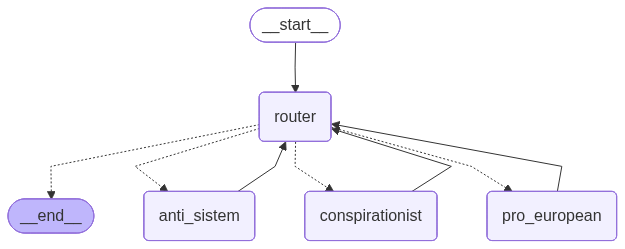

In [48]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

În acest graf, fiecare agent se întoarce la `router` deoarece routerul trebuie să decidă următorul pas:
- continuăm conversația?
- cine vorbește mai departe?
- sau ne oprim la `END`?
### TODO
De ce fiecare `agent_node` se întoarce la `router` și nu merge direct la următorul agent?

## 11. Rulăm primul thread multi-agent
Acum rulăm graful complet.
Folosim același stimulus politic și trei agenți:
```text
anti_sistem
conspirationist
pro_european

In [49]:
initial_state = {
    "stimulus": "CCR a decis anularea alegerilor după suspiciuni privind influențe externe.",
    "messages": [],
    "active_slugs": ["anti_sistem", "conspirationist", "pro_european"],
    "total_turns": 4,
    "current_turn": 0,
    "next_slug": "",
    "provider": "gemini",
    "k": 3
}

final_state = graph.invoke(initial_state)

print(thread_to_text(final_state["messages"]))

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7663.96it/s]


Turn 1 — @LibertateRO99: Păi normal că se anulează, că altfel ieșea cine nu trebuia și se stricau jocurile lor! Asta e țara unde legile se fac și se desfac după cum le convine lor, iar noi, proștii, stăm și ne uităm cum ne fură pe față!
Turn 2 — @AdevarulViu: @LibertateRO99, exact asta zic și eu, nu e deloc întâmplător că CCR a intervenit acum, când se vede clar că marile jocuri de culise sunt pe cale să fie date peste cap. Cine controlează de fapt aceste decizii și ce interese externe se ascund în spatele lor, asta e întrebarea reală.
Turn 3 — @EuroOptimistRO: @AdevarulViu, speculațiile despre jocuri de culise și interese externe, fără dovezi concrete, alimentează doar neîncrederea în instituții. Deciziile CCR trebuie analizate prin prisma respectării procedurilor legale și a Constituției, nu prin prisma unor teorii conspiraționiste.
Turn 4 — @LibertateRO99: @EuroOptimistRO, ce dovezi vrei, măi omule, când totul e la vedere? Pensiile alea speciale, dosarele alea făcute pe comandă, abu

## 12. Vizualizăm thread-ul
În aplicație, conversația nu va fi afișată ca tabel, ci ca o listă de mesaje/carduri. De aceea facem aceeași logică și în notebook: transformăm lista `messages` într-un bloc HTML ușor de citit.
Scopul vizualizării:
- verificăm ordinea intervențiilor;
- vedem ce agent a vorbit;
- citim conversația ca thread, nu ca listă brută de dicționare.

In [52]:
from IPython.display import HTML, display
import html

AGENT_COLORS = {
    "anti_sistem": "#e05a35",
    "conspirationist": "#9b5de5",
    "pro_european": "#4a9eff",
    "anti_suveranist": "#00a896",
    "personalist_salvator": "#f4a261",
}

def show_thread_cards(messages):
    cards = []

    for msg in messages:
        slug = msg.get("slug", "")
        color = AGENT_COLORS.get(slug, "#777")
        agent = html.escape(str(msg.get("agent", slug)))
        handle = html.escape(str(msg.get("handle", HANDLES.get(slug, slug))))
        text = html.escape(str(msg.get("text", "")))
        turn = msg.get("turn", "")

        card = f"""
        <div style="
            background:#16161a;
            border-left:3px solid {color};
            border-top:1px solid #1e1e28;
            border-right:1px solid #1e1e28;
            border-bottom:1px solid #1e1e28;
            padding:12px 14px;
            margin:8px 0;
            font-family:'Courier New', monospace;
        ">
            <div style="
                display:flex;
                align-items:baseline;
                gap:10px;
                margin-bottom:6px;
            ">
                <span style="
                    color:{color};
                    font-size:12px;
                    font-weight:700;
                    letter-spacing:.08em;
                    text-transform:uppercase;
                ">
                    {agent}
                </span>

                <span style="
                    color:#9a969f;
                    font-size:12px;
                    font-weight:500;
                ">
                    {handle}
                </span>

                <span style="
                    margin-left:auto;
                    color:#5a5660;
                    font-size:11px;
                ">
                    #{turn}
                </span>
            </div>

            <div style="
                color:#c0bcb6;
                font-size:13px;
                line-height:1.6;
            ">
                {text}
            </div>
        </div>
        """
        cards.append(card)

    display(HTML("\n".join(cards)))

show_thread_cards(final_state["messages"])

## 13. Variante avansate
Ce am construit până acum este varianta minimă: router simplu + thread multi-agent.
Pentru C7 este suficient. Mai jos sunt extensii posibile pentru aplicația finală.
| Extensie | Ce face | Când merită |
|---|---|---|
| Router LLM | modelul decide cine vorbește următorul | când vrem conversații mai dinamice |
| RSS starter | stimulusul vine dintr-o știre reală | când vrem un demo mai realist |
| Critic agent | marchează probleme în thread | când vrem evaluare sau moderare |
| Human review | omul validează thread-ul | când aplicația este publică sau sensibilă |
| Checkpointing | salvează starea grafului | pentru sesiuni lungi, debug sau reluare |
Important:
```text
C7 obligatoriu = router simplu + thread multi-agent.


## 14. Extensie opțională: Router LLM
Până acum routerul alegea agenții în ordine fixă:
`anti_sistem → conspirationist → pro_european → ...`
Acum testăm o variantă mai agentică: modelul citește conversația și decide cine ar trebui să răspundă următorul.
Schimbăm doar routerul. Nodurile agenților rămân aceleași.

### router LLM:

In [61]:
from core.agent import make_llm

def router_node_llm(state: ThreadState):
    # Oprim conversația dacă am ajuns la numărul maxim de intervenții
    if state["current_turn"] >= state["total_turns"]:
        return {"next_slug": "__end__"}

    active_slugs = state["active_slugs"]

    # Dacă nu există încă mesaje, începem cu primul agent
    if not state["messages"]:
        return {"next_slug": active_slugs[0]}

    # Nu lăsăm același agent să vorbească de două ori la rând
    last_slug = state["messages"][-1]["slug"]
    candidates = [slug for slug in active_slugs if slug != last_slug]

    if not candidates:
        candidates = active_slugs

    options = "\n".join(
        f"- {slug}: {HANDLES.get(slug, slug)}"
        for slug in candidates
    )

    prompt = f"""
Ai o conversație între agenți.

[STIMULUS]
{state["stimulus"]}

[THREAD]
{thread_to_text(state["messages"])}

[Agenți disponibili]
{options}

Alege agentul care ar trebui să răspundă următorul.
Nu alege agentul care tocmai a vorbit.
Răspunde doar cu slug-ul exact al agentului.
"""

    llm = make_llm(provider=state["provider"], temperature=0.1)
    response = llm.invoke(prompt)

    chosen = response.content.strip().lower()

    # Acceptăm răspunsul doar dacă este un candidat valid
    if chosen in candidates:
        return {"next_slug": chosen}

    # Fallback: alegem primul candidat permis
    return {"next_slug": candidates[0]}

### construim graful cu router LLM

In [62]:
from langgraph.graph import StateGraph, START, END

def route_decision(state: ThreadState):
    return state["next_slug"]

active_slugs = ["anti_sistem", "conspirationist", "pro_european"]

workflow_llm_router = StateGraph(ThreadState)

# Folosim routerul LLM în locul routerului round-robin
workflow_llm_router.add_node("router", router_node_llm)

# Nodurile agenților rămân aceleași
for slug in active_slugs:
    workflow_llm_router.add_node(slug, make_agent_node(slug))

workflow_llm_router.add_edge(START, "router")

workflow_llm_router.add_conditional_edges(
    "router",
    route_decision,
    {
        "anti_sistem": "anti_sistem",
        "conspirationist": "conspirationist",
        "pro_european": "pro_european",
        "__end__": END
    }
)

for slug in active_slugs:
    workflow_llm_router.add_edge(slug, "router")

graph_llm_router = workflow_llm_router.compile()

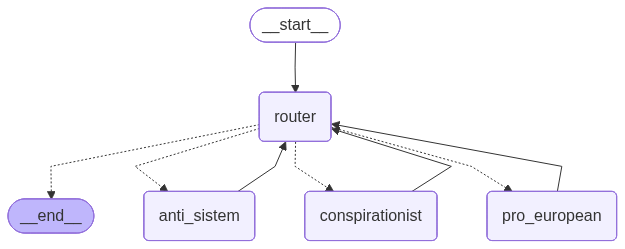

In [63]:
from IPython.display import Image, display

display(Image(graph_llm_router.get_graph().draw_mermaid_png()))

In [66]:
# rulare
initial_state_llm_router = {
    "stimulus": "CCR a decis anularea alegerilor după suspiciuni privind influențe externe.",
    "messages": [],
    "active_slugs": ["anti_sistem", "conspirationist", "pro_european"],
    "total_turns": 4,
    "current_turn": 0,
    "next_slug": "",
    "provider": "deepseek",
    "k": 3
}

final_state_llm_router = graph_llm_router.invoke(initial_state_llm_router)

print(thread_to_text(final_state_llm_router["messages"]))

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10052.95it/s]


Turn 1 — @LibertateRO99: @LibertateRO99: Păi bravo lor, au găsit acum scuza cu influențe externe după ce au stat și au privit cum ne fură ăștia de zeci de ani în față. Să anulezi niște alegeri pentru că nu-ți place rezultatul e culmea tupeului, dar la pensiile speciale și dosarele cu șpăgi nu mai are nimeni curaj să pună tunul. Rușine, mă, că ne tratați ca pe niște proști și ne tot băgați minciuni pe gât.
Turn 2 — @AdevarulViu: @LibertateRO99: Ai dreptate că e suspect momentul, dar nu e deloc întâmplător că exact acum se activează această decizie, când serviciile și rețelele externe își joacă ultimele cărți în România. Cine controlează de fapt butoanele astea de la CCR știe bine că nu e vorba de vot, ci de cine trage sforile din umbră.
Turn 3 — @EuroOptimistRO: @AdevarulViu: Nu e vorba de cine trage sforile din umbră, ci de niște documente desecretizate ale CSAT care arată exact ce fluxuri de bani și influență au venit din exterior. CCR nu a anulat alegerile pentru că nu i-a plăcut rez

In [67]:
show_thread_cards(final_state_llm_router["messages"])

!!!!!!aci e gresit

 17. Extragem codul în `core/graph.py`
Până acum am construit graful în notebook. Următorul pas este să mutăm logica într-un fișier reutilizabil:
```text
core/graph.py

De ce facem asta:

notebook-ul este bun pentru învățare și testare;
core/graph.py este bun pentru aplicație;
app.py va putea apela direct run_thread().
Funcția principală va fi:
run_thread(stimulus, active_slugs, total_turns=4, provider="gemini", k=3)

## 18. Integrare minimă în aplicație
După ce `core/graph.py` funcționează, aplicația poate apela direct funcția:
```python
run_thread()

### Test din terminal
După ce salvați fișierul `core/graph.py`, rulați din rădăcina proiectului:
```bash
python -m core.graph --agents anti_sistem conspirationist pro_european --text "CCR a decis anularea alegerilor după suspiciuni privind influențe externe." --turns 4 --provider gemini

Pentru C7 nu construim încă interfața finală. Pregătim doar ideea unui tab nou:

Multi-agent thread

Inputuri minime:

Input	Rol
stimulus	textul politic / știrea de la care pornește conversația
active_slugs	agenții care participă
total_turns	numărul de intervenții
provider	modelul folosit: gemini sau deepseek
Output:	
Output	Rol
---	---
thread	lista de mesaje generate de agenți
vizualizare HTML	conversația afișată ca mesaje/carduri
Structura minimă în aplicație:	
stimulus + agenți + număr runde
        ↓
run_thread()
        ↓
thread generat
        ↓
afișare ca listă de mesaje

Pentru C8 putem îmbunătăți interfața cu:

carduri pe culorile agenților;
export JSONL;
afișarea surselor RAG;
metrici simple;
disclaimer și limitări.
Notă:
Dacă nu este timp în C7, integrarea completă în app.py rămâne pentru C8.
Mini-task

Ce trebuie să afișeze aplicația pentru ca thread-ul să fie interpretabil?
Completează tabelul:

Element afișat	De ce este util?
numele agentului	...
handle-ul agentului	...
numărul intervenției	...
textul intervenției	...
contextul RAG / sursele	...

## 19. Etică și limite
Un sistem multi-agent care simulează bule discursive poate fi util pentru cercetare și educație, dar are limite clare. Agenții nu sunt persoane reale. Ei nu exprimă opinii autentice, ci generează răspunsuri pe baza unui rol definit în YAML, a unui corpus de comentarii și a unui model lingvistic.
Aceste răspunsuri nu trebuie citite ca adevăr factual. Ele sunt simulări discursive: arată cum poate fi reprodus un anumit stil de interpretare, nu ce „gândește” un grup social real.
Riscuri principale:
| Risc | Ce înseamnă |
|---|---|
| Antropomorfizare | putem ajunge să tratăm agenții ca persoane reale |
| Halucinație | modelul poate adăuga afirmații care nu sunt susținute de context |
| Amplificare discursivă | interacțiunea multi-agent poate intensifica conflictul sau polarizarea |
| Bias din corpus | corpusul poate conține limbaj problematic, stereotipuri sau dezechilibre |
| Confuzie metodologică | simularea nu înlocuiește analiza empirică a actorilor reali |
Regulă de prezentare:
```text
EchoChamber este un instrument de simulare și analiză discursivă, nu un sistem de predicție politică și nu o reprezentare fidelă a unor persoane reale.

Scrie un disclaimer de 3–4 fraze pentru aplicația EchoChamber.

Pentru fișierul `docs/ethics_and_limits.md`, aș folosi asta:
```markdown
# Ethics and limitations
EchoChamber simulates discursive agents based on role prompts, retrieved corpus fragments, and LLM-generated responses. The agents are not real people and do not represent actual individuals, parties, voters, communities, or demographic groups.
The system should be used as an educational and research prototype for exploring discourse, framing, and interaction patterns. It should not be used to infer what real social groups believe, predict political behavior, or produce factual claims about public events.
## Main limitations
| Limitation | Explanation |
|---|---|
| Simulated agents | Agents reproduce a constructed discursive role, not real human agency. |
| Corpus bias | The corpus may contain biased, extreme, repetitive, or unbalanced comments. |
| Unsupported claims | The model may generate claims that are not directly supported by the retrieved context. |
| Amplification | Multi-agent interaction can intensify conflict, repetition, or conspiratorial framing. |
| No factual authority | Generated responses are not verified facts and should not be presented as evidence. |
| Interpretive use only | Outputs require human interpretation and methodological caution. |
## Required disclaimer
This application generates simulated political-discourse responses. The agents are fictional analytical constructs, not real people or representatives of real groups. The generated text may contain bias, exaggeration, unsupported claims, or problematic language inherited from the corpus and the model. Outputs should be used only for education, prototyping, and critical discourse analysis.
## Responsible use
Use the system to inspect how discourse can be structured, amplified, or contrasted across roles. Do not use it to profile individuals, target groups, generate political persuasion, or present synthetic responses as empirical public opinion.

Pentru README.md, pune doar scurt:

## Ethics and limitations
EchoChamber is a teaching and research prototype. Its agents are simulated discursive roles, not real people or representatives of real social groups. Generated outputs may include bias, unsupported claims, or amplified conflict and must be interpreted critically.
See [`docs/ethics_and_limits.md`](docs/ethics_and_limits.md) for the full disclaimer and limitations.